In [1]:
import matplotlib
import matplotlib.pyplot as plt
#from collections import OrderedDict
import seaborn as sns

import numpy as np
import os
import scipy
import pickle

from neurolib.models.aln import ALNModel
import neurolib.utils.functions as func
from neurolib.utils import costFunctions as cost
from neurolib.utils import plotFunctions as plotFunc
from neurolib.models import jacobian_aln as jac_aln

# a nice color map
#sns.set()
#cmap = plt.get_cmap('plasma')
plt.rcParams['image.cmap'] = 'plasma'
cpalette = sns.color_palette('plasma')
np.set_printoptions(precision=4)

#matplotlib.style.use('classic')

font = {
    'family' : 'sans',
    'weight' : 'normal',
    'size'   : 14
       }

matplotlib.rc('font', **font)
matplotlib.rc('xtick', labelsize=16) 
matplotlib.rc('ytick', labelsize=16) 
matplotlib.rc('grid', c='0.5', ls='-', lw=0.5)  # solid gray grid lines
matplotlib.rc('savefig', dpi=300)       # higher res outputs
#print (matplotlib.rcParams)
    
# This will reload all imports as soon as the code changes
%load_ext autoreload
%autoreload 2 

path = os.getcwd()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Bistability

In [2]:
def step_control(maxI_ = 1.):
    control_ = aln.getZeroControl()
    for i_time in range(control_.shape[2]):
        if ( float(i_time/control_.shape[2]) < 0.1):
            control_[:,:,i_time] = - maxI_
        elif ( float(i_time/control_.shape[2]) > 0.5 and float(i_time/control_.shape[2]) < 0.6 ):
            control_[:,:,i_time] = maxI_
    return control_

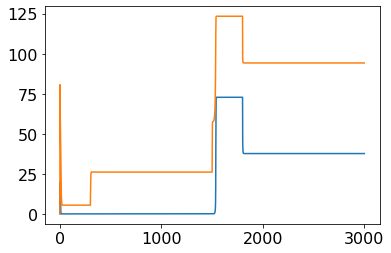

[[2.3474e-04 2.6062e+01]
 [3.7674e+01 9.4217e+01]]


In [3]:
aln = ALNModel()

aln.params['duration'] = 3000.

control0 = aln.getZeroControl()
target = aln.getZeroTarget()
control0 = step_control(maxI_ = 1.)

aln.params.ext_exc_current = 2.3
aln.params.ext_inh_current = 2.5

# no delay
aln.params.signalV = 0.
aln.params.de = 0.
aln.params.di = 0.

# NO ADAPTATION
aln.params.IA_init = np.array([0.])
aln.params.a = 0.
aln.params.b = 0.

aln.params.mue_ext_mean = 0.0
aln.params.mui_ext_mean = 0.0

state = aln.getZeroState()
aln.run(control = control0)

plt.plot(aln.t, aln.rates_exc[0,:])
plt.plot(aln.t, aln.rates_inh[0,:])
plt.show()

output = aln.output_vars

for i in range(len(output)):
    state[:,i,:] = aln[output[i]][:,:]
    
steady_rates = np.zeros((2, 2))
steady_rates[0,0] = np.mean(state[0,0,3000:15000]) # low state exc
steady_rates[0,1] = np.mean(state[0,1,3000:15000]) # low state inh
steady_rates[1,0] = np.mean(state[0,0,19500:]) # high state exc
steady_rates[1,1] = np.mean(state[0,1,19500:]) #high state inh

print(steady_rates)

state_vars = aln.state_vars
init_vars = aln.init_vars

high_state_vars = np.zeros(( len(state_vars) ))
for i in range(len(state_vars)):
    #print("final value of state var ", aln.state_vars[i], " : ", aln.state[state_vars[i]])
    if aln.state[state_vars[i]].size == 1:
        high_state_vars[i] = aln.state[state_vars[i]][0] * 1.01
    else:
        high_state_vars[i] = aln.state[state_vars[i]][0,-1] * 1.01

low state vars =  [ 8.3127e-005  2.5847e+001 -3.3072e-001  1.0327e+000  0.0000e+000
  1.6420e-005  7.9023e-001  1.5346e-005  8.7951e-001  1.0135e-006
  2.5945e-003  8.8534e-007  1.9317e-003  2.3986e-264  1.7990e-264
  1.5030e+000  1.4869e+000 -7.0969e+001  2.1153e+001  2.3058e+000]


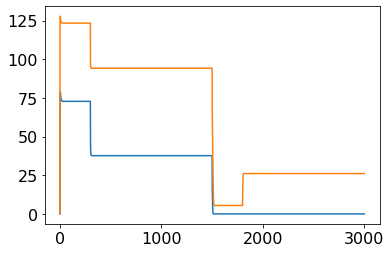

In [4]:
control0 = step_control(maxI_ = -1.)
aln.run(control = control0)
plt.plot(aln.t, aln.rates_exc[0,:])
plt.plot(aln.t, aln.rates_inh[0,:])

low_state_vars = np.zeros(( len(state_vars) ))
for i in range(len(state_vars)):
    #print("final value of state var ", aln.state_vars[i], " : ", aln.state[state_vars[i]])
    if aln.state[state_vars[i]].size == 1:
        low_state_vars[i] = aln.state[state_vars[i]][0] * 0.99
    else:
        low_state_vars[i] = aln.state[state_vars[i]][0,-1] * 0.99

print("low state vars = ", low_state_vars)

### State switching task in bistability regime: Switch from up to down state

In [5]:
dur = 15.
dur_pre = 5.
dur_post = 5.
aln.params.duration = dur

control0 = aln.getZeroControl()

# set high state rates as target
target_lh = aln.getZeroTarget()
target_lh[:,0,:] = steady_rates[1,0]
target_lh[:,1,:] = steady_rates[1,1] 

max_it = 5
tol = 1e-12
incl_step = int(1. + aln.params.duration/aln.params.dt)
start_step = 10.
test_step = 1e-6

c_scheme = np.zeros(( 1,1 ))
c_scheme[0,0] = 1.
u_mat = np.identity(1)
u_scheme = np.array([[1.]])

alg = "A1"
#alg = "A2"

plot_only = False

In [6]:
# D: precision & energy equally penalize, max 1nA control
cost.setParams(1.0, 1.0, 0.)
max_cntrl = 1. * 5.

def setinitvars(vars):
    for iv in range(len(init_vars)):
        for sv in range(len(state_vars)):
            if state_vars[sv] in init_vars[iv]:
                if aln.params[init_vars[iv]].ndim == 2:
                    aln.params[init_vars[iv]][0,0] = vars[sv]
                else:
                    aln.params[init_vars[iv]][0] = vars[sv]
                
opt_params = {"max_it": max_it,
              "tol": tol,
              "incl_step": incl_step,
              "start_step": start_step,
              "test_step": test_step,
              "dur": dur,
              "dur_pre": dur_pre,
              "dur_post": dur_post,
}

set cost params


In [23]:
k = 2.
for i in range(9):
    k = k * 0.8
    print(k)

1.6
1.2800000000000002
1.0240000000000002
0.8192000000000003
0.6553600000000003
0.5242880000000002
0.4194304000000002
0.3355443200000002
0.2684354560000001


In [35]:
setinitvars(low_state_vars)
max_it = 50
alg = "A1"

if not plot_only:
    if alg == "A1":
        bestControlH, bestStateH, costH, runtimeH = aln.A1(control0, target_lh, c_scheme, u_mat, u_scheme,
            max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post)
    elif alg == "A2":
        bestControlH, bestStateH, costH, runtimeH = aln.A2(control0, target_lh, max_iteration_ = max_it,
                    tolerance_ = tol, include_timestep_ = incl_step, start_step_ = start_step, test_step_ = test_step,
                    max_control_ = max_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post)

    resultH = {"Opt_control": bestControlH,
              "Opt_state": bestStateH,
              "costArray": costH,
              "runtimeArray": runtimeH,    
    }

    dump_dicts = [opt_params, aln.params, resultH]
    filename = str("H_" + alg + ".p")
    pickle.dump( dump_dicts, open( filename, "wb" ) )

RUN  0 , total integrated cost =  45740.55028557171
step =  10.0  , cost =  86613.77836688825 , initial cost =  45740.55028557171
step =  5.0  , cost =  56975.18578814885 , initial cost =  45740.55028557171
step =  2.5  , cost =  41157.99963631325 , initial cost =  45740.55028557171
step =  1.25  , cost =  40968.383660743595 , initial cost =  45740.55028557171
step =  0.625  , cost =  40963.834293144624 , initial cost =  45740.55028557171
step =  0.3125  , cost =  40963.060354960304 , initial cost =  45740.55028557171
step =  0.15625  , cost =  40962.86876532774 , initial cost =  45740.55028557171
step =  0.078125  , cost =  40962.81564319142 , initial cost =  45740.55028557171
step =  0.0390625  , cost =  40919.11711554962 , initial cost =  45740.55028557171
step =  0.01953125  , cost =  40752.902159761215 , initial cost =  45740.55028557171
step =  0.009765625  , cost =  40381.392729488 , initial cost =  45740.55028557171
step =  0.0048828125  , cost =  39412.65328755849 , initial co

step =  4.547473508864641e-12  , cost =  11659.978591285682 , initial cost =  11608.042779891615
step =  2.2737367544323206e-12  , cost =  11659.97859130892 , initial cost =  11608.042779891615
step =  1.1368683772161603e-12  , cost =  11659.978591320525 , initial cost =  11608.042779891615
step =  5.684341886080801e-13  , cost =  11659.978591326344 , initial cost =  11608.042779891615
step =  2.8421709430404007e-13  , cost =  11659.978591329253 , initial cost =  11608.042779891615
step =  1.4210854715202004e-13  , cost =  11659.978591330691 , initial cost =  11608.042779891615
step =  7.105427357601002e-14  , cost =  11659.978591331423 , initial cost =  11608.042779891615
step =  3.552713678800501e-14  , cost =  11659.978591331785 , initial cost =  11608.042779891615
step =  1.7763568394002505e-14  , cost =  11659.978591331968 , initial cost =  11608.042779891615
step =  8.881784197001252e-15  , cost =  11659.97859133206 , initial cost =  11608.042779891615
step =  4.440892098500626e-

step =  1.1479437019748901e-40  , cost =  11659.97859133215 , initial cost =  11608.042779891615
step =  5.739718509874451e-41  , cost =  11659.97859133215 , initial cost =  11608.042779891615
step =  2.8698592549372254e-41  , cost =  11659.97859133215 , initial cost =  11608.042779891615
step =  1.4349296274686127e-41  , cost =  11659.97859133215 , initial cost =  11608.042779891615
step =  7.174648137343063e-42  , cost =  11659.97859133215 , initial cost =  11608.042779891615
step =  3.587324068671532e-42  , cost =  11659.97859133215 , initial cost =  11608.042779891615
step =  1.793662034335766e-42  , cost =  11659.97859133215 , initial cost =  11608.042779891615
step =  8.96831017167883e-43  , cost =  11659.97859133215 , initial cost =  11608.042779891615
step =  4.484155085839415e-43  , cost =  11659.97859133215 , initial cost =  11608.042779891615
step =  2.2420775429197073e-43  , cost =  11659.97859133215 , initial cost =  11608.042779891615
step =  1.1210387714598537e-43  , cos

step =  1.8546030753437107e-67  , cost =  11659.97859133215 , initial cost =  11608.042779891615
step =  9.273015376718553e-68  , cost =  11659.97859133215 , initial cost =  11608.042779891615
step =  4.636507688359277e-68  , cost =  11659.97859133215 , initial cost =  11608.042779891615
step =  2.3182538441796384e-68  , cost =  11659.97859133215 , initial cost =  11608.042779891615
step =  1.1591269220898192e-68  , cost =  11659.97859133215 , initial cost =  11608.042779891615
step =  5.795634610449096e-69  , cost =  11659.97859133215 , initial cost =  11608.042779891615
step =  2.897817305224548e-69  , cost =  11659.97859133215 , initial cost =  11608.042779891615
step =  1.448908652612274e-69  , cost =  11659.97859133215 , initial cost =  11608.042779891615
step =  7.24454326306137e-70  , cost =  11659.97859133215 , initial cost =  11608.042779891615
step =  3.622271631530685e-70  , cost =  11659.97859133215 , initial cost =  11608.042779891615
step =  1.8111358157653425e-70  , cost

step =  2.3970182936024055e-93  , cost =  11659.97859133215 , initial cost =  11608.042779891615
step =  1.1985091468012028e-93  , cost =  11659.97859133215 , initial cost =  11608.042779891615
step =  5.992545734006014e-94  , cost =  11659.97859133215 , initial cost =  11608.042779891615
step =  2.996272867003007e-94  , cost =  11659.97859133215 , initial cost =  11608.042779891615
step =  1.4981364335015035e-94  , cost =  11659.97859133215 , initial cost =  11608.042779891615
step =  7.490682167507517e-95  , cost =  11659.97859133215 , initial cost =  11608.042779891615
step =  3.7453410837537587e-95  , cost =  11659.97859133215 , initial cost =  11608.042779891615
step =  1.8726705418768793e-95  , cost =  11659.97859133215 , initial cost =  11608.042779891615
step =  9.363352709384397e-96  , cost =  11659.97859133215 , initial cost =  11608.042779891615
step =  4.681676354692198e-96  , cost =  11659.97859133215 , initial cost =  11608.042779891615
step =  2.340838177346099e-96  , co

...

step =  1.572546086327425e-234  , cost =  11659.97859133215 , initial cost =  11608.042779891615
step =  7.862730431637126e-235  , cost =  11659.97859133215 , initial cost =  11608.042779891615
step =  3.931365215818563e-235  , cost =  11659.97859133215 , initial cost =  11608.042779891615
step =  1.9656826079092814e-235  , cost =  11659.97859133215 , initial cost =  11608.042779891615
step =  9.828413039546407e-236  , cost =  11659.97859133215 , initial cost =  11608.042779891615
step =  4.9142065197732035e-236  , cost =  11659.97859133215 , initial cost =  11608.042779891615
step =  2.4571032598866018e-236  , cost =  11659.97859133215 , initial cost =  11608.042779891615
step =  1.2285516299433009e-236  , cost =  11659.97859133215 , initial cost =  11608.042779891615
step =  6.142758149716504e-237  , cost =  11659.97859133215 , initial cost =  11608.042779891615
step =  3.071379074858252e-237  , cost =  11659.97859133215 , initial cost =  11608.042779891615
step =  1.535689537429126e

step =  2.5405852245238005e-261  , cost =  11659.97859133215 , initial cost =  11608.042779891615
step =  1.2702926122619002e-261  , cost =  11659.97859133215 , initial cost =  11608.042779891615
step =  6.351463061309501e-262  , cost =  11659.97859133215 , initial cost =  11608.042779891615
step =  3.1757315306547506e-262  , cost =  11659.97859133215 , initial cost =  11608.042779891615
step =  1.5878657653273753e-262  , cost =  11659.97859133215 , initial cost =  11608.042779891615
step =  7.939328826636877e-263  , cost =  11659.97859133215 , initial cost =  11608.042779891615
step =  3.969664413318438e-263  , cost =  11659.97859133215 , initial cost =  11608.042779891615
step =  1.984832206659219e-263  , cost =  11659.97859133215 , initial cost =  11608.042779891615
step =  9.924161033296096e-264  , cost =  11659.97859133215 , initial cost =  11608.042779891615
step =  4.962080516648048e-264  , cost =  11659.97859133215 , initial cost =  11608.042779891615
step =  2.481040258324024e

step =  1.026134200324594e-288  , cost =  11659.97859133215 , initial cost =  11608.042779891615
step =  5.13067100162297e-289  , cost =  11659.97859133215 , initial cost =  11608.042779891615
step =  2.565335500811485e-289  , cost =  11659.97859133215 , initial cost =  11608.042779891615
step =  1.2826677504057426e-289  , cost =  11659.97859133215 , initial cost =  11608.042779891615
step =  6.413338752028713e-290  , cost =  11659.97859133215 , initial cost =  11608.042779891615
step =  3.2066693760143564e-290  , cost =  11659.97859133215 , initial cost =  11608.042779891615
step =  1.6033346880071782e-290  , cost =  11659.97859133215 , initial cost =  11608.042779891615
step =  8.016673440035891e-291  , cost =  11659.97859133215 , initial cost =  11608.042779891615
step =  4.0083367200179456e-291  , cost =  11659.97859133215 , initial cost =  11608.042779891615
step =  2.0041683600089728e-291  , cost =  11659.97859133215 , initial cost =  11608.042779891615
step =  1.0020841800044864

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


step =  3.7330544740128755e-300  , cost =  11659.97859133215 , initial cost =  11608.042779891615
control too big, but no further iteration
step size =  0.0 11608.042779891615
RUN  5 , total integrated cost =  11608.042779891615
Control only changes marginally.
Improved over  5  iterations by  74.6219870390295  percent.
max value of final gradient at index =  (array([0], dtype=int64), array([1], dtype=int64), array([7], dtype=int64)) 96.11585287037813
min value of final gradient at index =  (array([0], dtype=int64), array([1], dtype=int64), array([1], dtype=int64)) -308.55318223998387


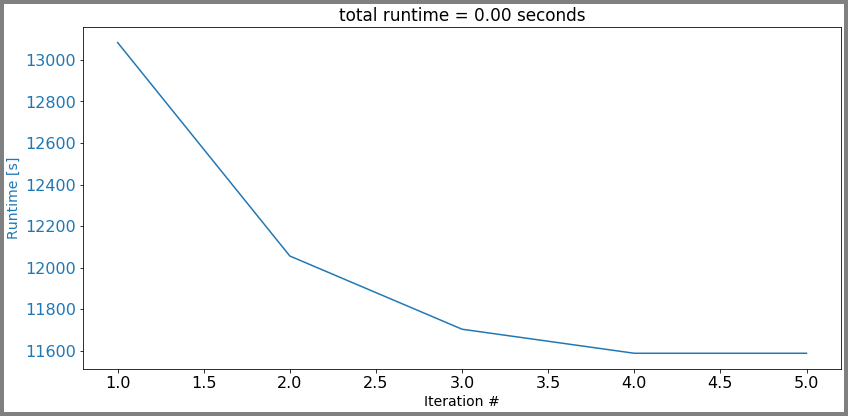

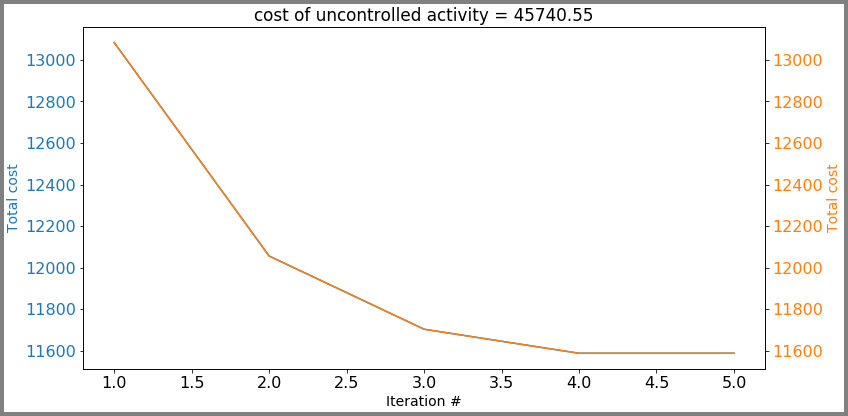

In [32]:
plotFunc.plot_runtime(costH, path, str("p1_e1_u1nA_LowHigh_runtime_" + alg) )
plotFunc.plot_convergence(costH, path, str("p1_e1_u1nA_LowHigh_cost_" + alg) )

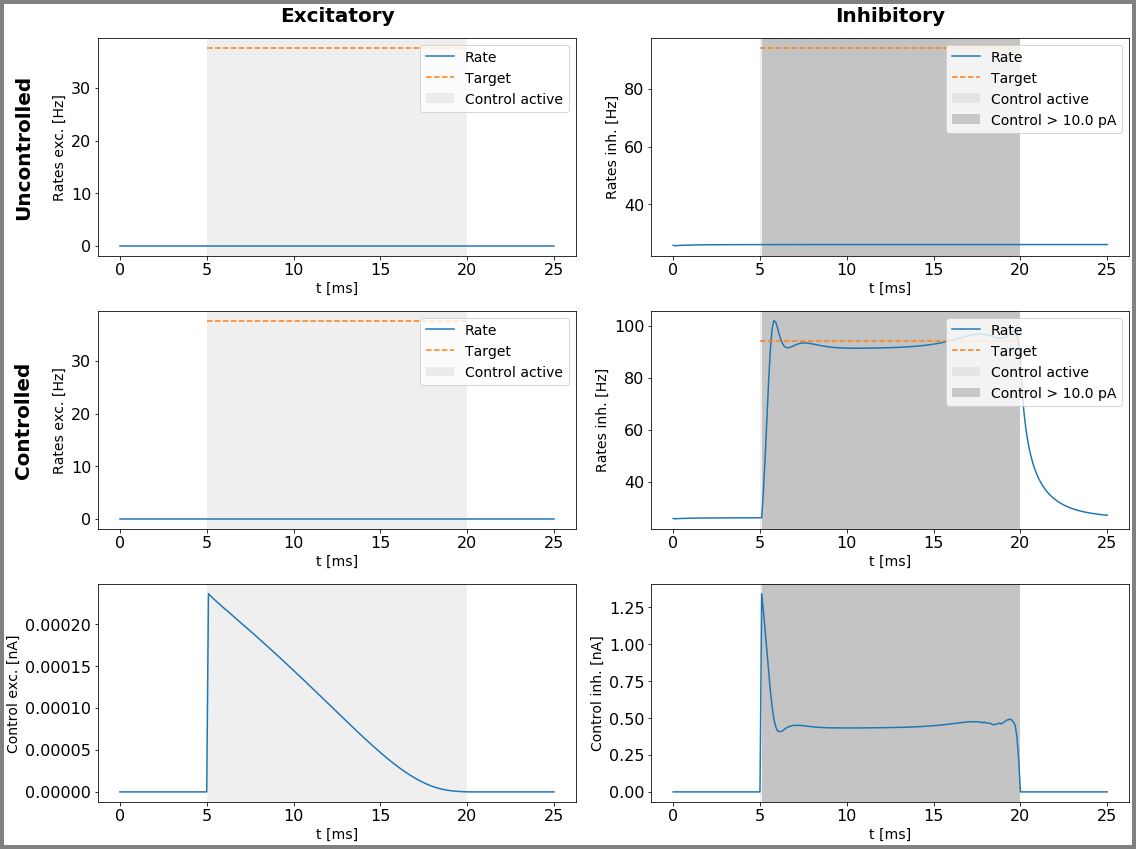

In [33]:
plotFunc.plot_control(aln, bestControlH, dur, dur_pre, dur_post, low_state_vars, target_lh,
                      path, filename_ = str('p1_e1_u1nA_LowHigh_' + alg))

In [28]:
cntrl1 = control0
alg = "A1"

max_it = 10
loop_it = 5
costA1 = np.zeros(max_it*loop_it + 1)
runtimeA1 = np.zeros(max_it*loop_it + 1)

#cntrl1 = cntrlA1_[:,:,50:201]

RUN  0 , total integrated cost =  45740.55028557171
step size exc =  3.8820528435882964
step size inh =  0.0012115544523144178
step size =  0.9030265957484525 12085.21217589436
step size =  0.0012148231392250866 13080.017942020424
choose separately
RUN  1 , total integrated cost =  12085.21217589436
step size exc =  0.00023884303539688286
step size inh =  0.001689684308429976
step size =  2.1745520870107704 9390.949892915569
step size =  0.00034179419053944655 11424.094317306544
choose separately
RUN  2 , total integrated cost =  9390.949892915569
step size exc =  0.00011982311842926349
step size inh =  0.0018463636652977624
step size =  0.9884327668230775 7155.989442468549
step size =  0.00020042860948910277 8875.916749579583
choose separately
RUN  3 , total integrated cost =  7155.989442468549
step size exc =  0.0004660829870992452
step size inh =  0.0014668667343984583
step size =  0.8223236385359143 6915.972831971869
step size =  0.0005378511359461014 6970.9172708841525
choose sepa

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


step size =  0.0007732171338435965 5866.909523251574
choose separately
RUN  10 , total integrated cost =  5861.107703365041
Improved over  10  iterations by  87.18618891383593  percent.
max value of final gradient at index =  (array([0], dtype=int64), array([0], dtype=int64), array([91], dtype=int64)) 340.6394186924548
min value of final gradient at index =  (array([0], dtype=int64), array([1], dtype=int64), array([1], dtype=int64)) -400.9058476364383
Problem in initial value trasfer for  sigmae_f
1.518235957096325
1.5182355652160797
Problem in initial value trasfer for  sigmai_f
1.501909936524541
1.5019098897679062
Problem in initial value trasfer for  tau_exc
21.356780408292302
21.356841639083466
Problem in initial value trasfer for  tau_inh
2.33029094029334
2.330218472786663
RUN  0 , total integrated cost =  5861.168309756761
step size exc =  0.0001234178119821414
step size inh =  0.0015459936609468936
step size =  1.0588332732298842 5755.543277563166
step size =  0.0001254874840277

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


step size =  0.0010426336756251308 4842.871673599844
choose separately
RUN  10 , total integrated cost =  4842.20344679352
Improved over  10  iterations by  17.385012835530205  percent.
max value of final gradient at index =  (array([0], dtype=int64), array([0], dtype=int64), array([71], dtype=int64)) 251.06294490840165
min value of final gradient at index =  (array([0], dtype=int64), array([1], dtype=int64), array([1], dtype=int64)) -389.7232854055576
Problem in initial value trasfer for  sigmae_f
1.518235957096325
1.5182355652160797
Problem in initial value trasfer for  sigmai_f
1.501909936524541
1.5019098897679062
Problem in initial value trasfer for  tau_exc
21.356780408292302
21.356841639083466
Problem in initial value trasfer for  tau_inh
2.33029094029334
2.330218472786663
RUN  0 , total integrated cost =  4842.2345716998925
step size exc =  0.00018155017943827795
step size inh =  0.0015536944223708998
step size =  1.0279934691552273 4783.548131280047
step size =  0.0001861329995

...

step size =  0.0014576626144662012 4179.620321050454
choose separately
RUN  10 , total integrated cost =  4179.6148597126385
Improved over  10  iterations by  13.684172094013974  percent.
max value of final gradient at index =  (array([0], dtype=int64), array([0], dtype=int64), array([59], dtype=int64)) 202.43796605474407
min value of final gradient at index =  (array([0], dtype=int64), array([1], dtype=int64), array([1], dtype=int64)) -376.63905185236547
Problem in initial value trasfer for  sigmae_f
1.518235957096325
1.5182355652160797
Problem in initial value trasfer for  sigmai_f
1.501909936524541
1.5019098897679062
Problem in initial value trasfer for  tau_exc
21.356780408292302
21.356841639083466
Problem in initial value trasfer for  tau_inh
2.33029094029334
2.330218472786663
RUN  0 , total integrated cost =  4179.679054683799
step size exc =  0.00023074338781210965
step size inh =  0.0015536944223708998
step size =  1.0348356140836181 4135.871792591023
step size =  0.00022967764

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


step size =  0.0018956975920456913 3689.4170191217268
choose separately
RUN  10 , total integrated cost =  3689.0417946644307
Improved over  10  iterations by  11.738634799472322  percent.
max value of final gradient at index =  (array([0], dtype=int64), array([0], dtype=int64), array([49], dtype=int64)) 158.98190370455686
min value of final gradient at index =  (array([0], dtype=int64), array([1], dtype=int64), array([1], dtype=int64)) -374.0181232162408
Problem in initial value trasfer for  sigmae_f
1.518235957096325
1.5182355652160797
Problem in initial value trasfer for  sigmai_f
1.501909936524541
1.5019098897679062
Problem in initial value trasfer for  tau_exc
21.356780408292302
21.356841639083466
Problem in initial value trasfer for  tau_inh
2.33029094029334
2.330218472786663
RUN  0 , total integrated cost =  3689.0588908254326
step size exc =  0.0005519726093810937
step size inh =  0.0016347794848178678
step size =  1.0246307289969117 3663.7134199556203
step size =  0.0005612289

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


step size =  0.0014361735781817854 3567.2818023567434
choose separately
RUN  10 , total integrated cost =  3567.2786652935965
Improved over  10  iterations by  3.3011190424392396  percent.
max value of final gradient at index =  (array([0], dtype=int64), array([0], dtype=int64), array([47], dtype=int64)) 71.018161575815
min value of final gradient at index =  (array([0], dtype=int64), array([1], dtype=int64), array([1], dtype=int64)) -360.7068802480109
Problem in initial value trasfer for  sigmae_f
1.518235957096325
1.5182355652160797
Problem in initial value trasfer for  sigmai_f
1.501909936524541
1.5019098897679062
Problem in initial value trasfer for  tau_exc
21.356780408292302
21.356841639083466
Problem in initial value trasfer for  tau_inh
2.33029094029334
2.330218472786663


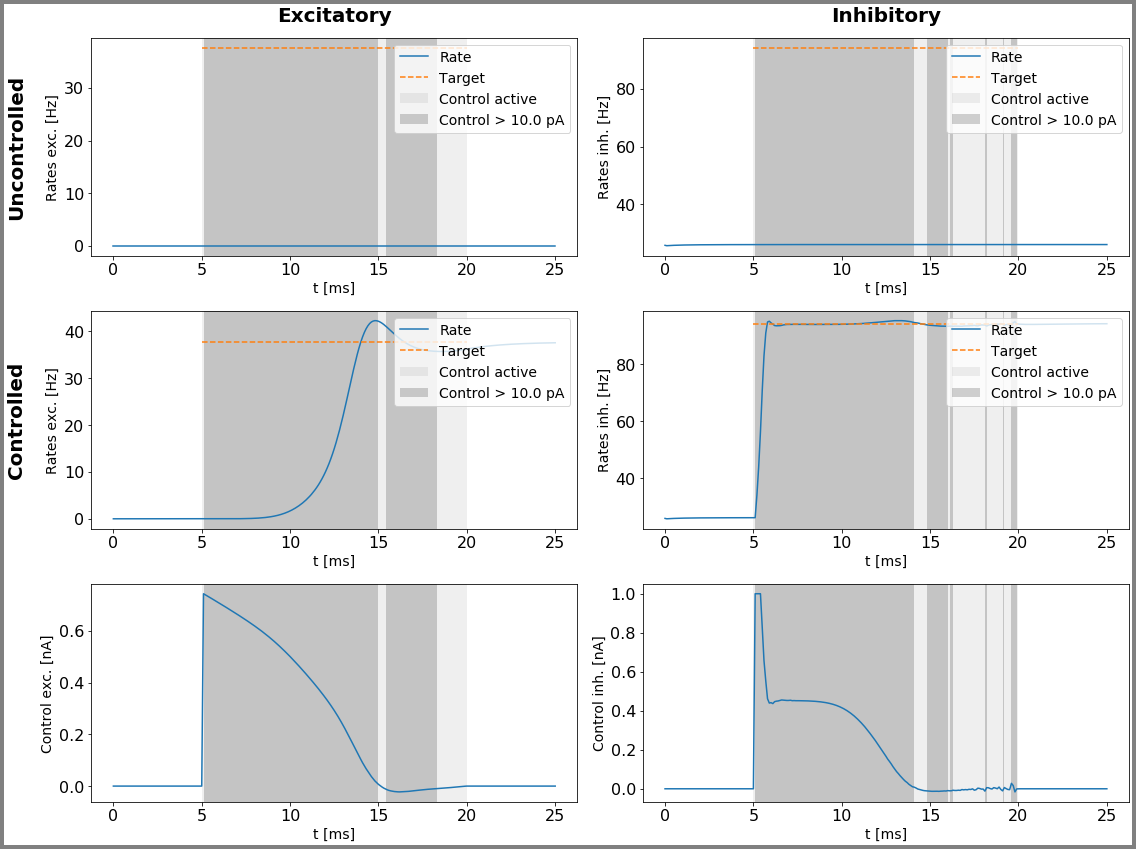

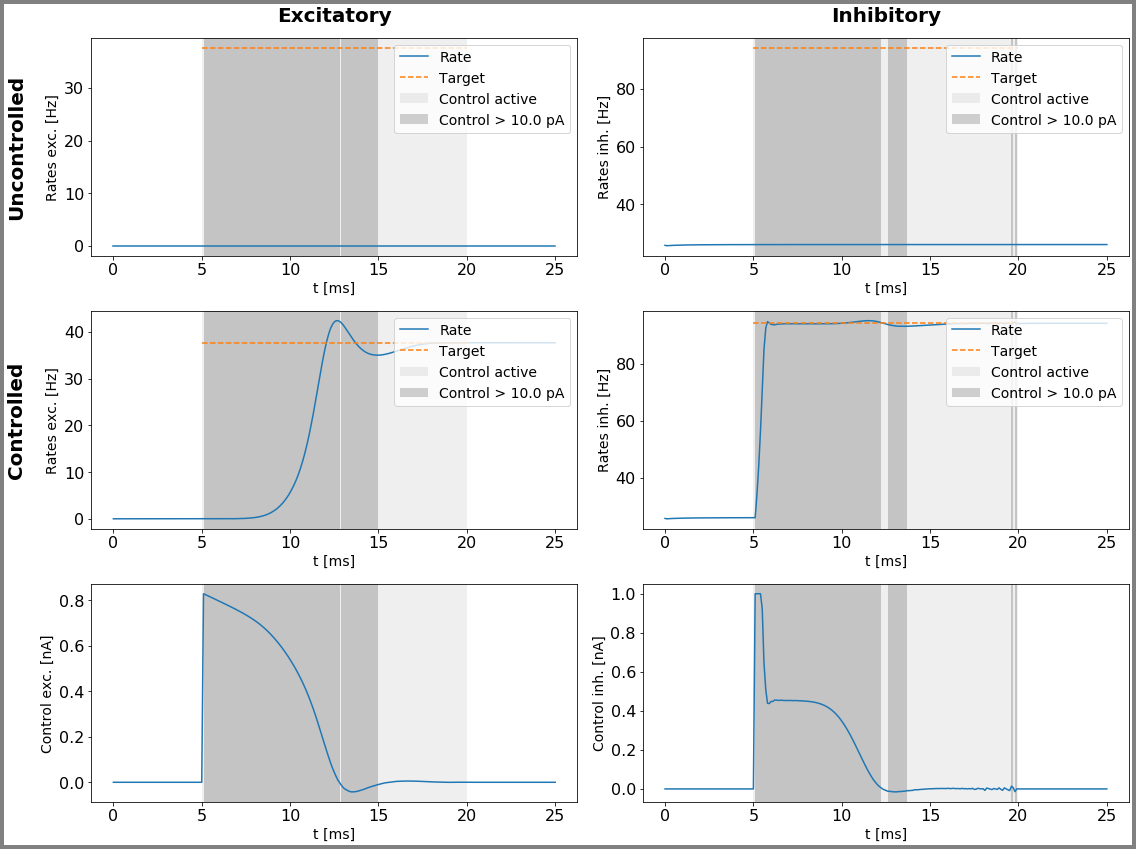

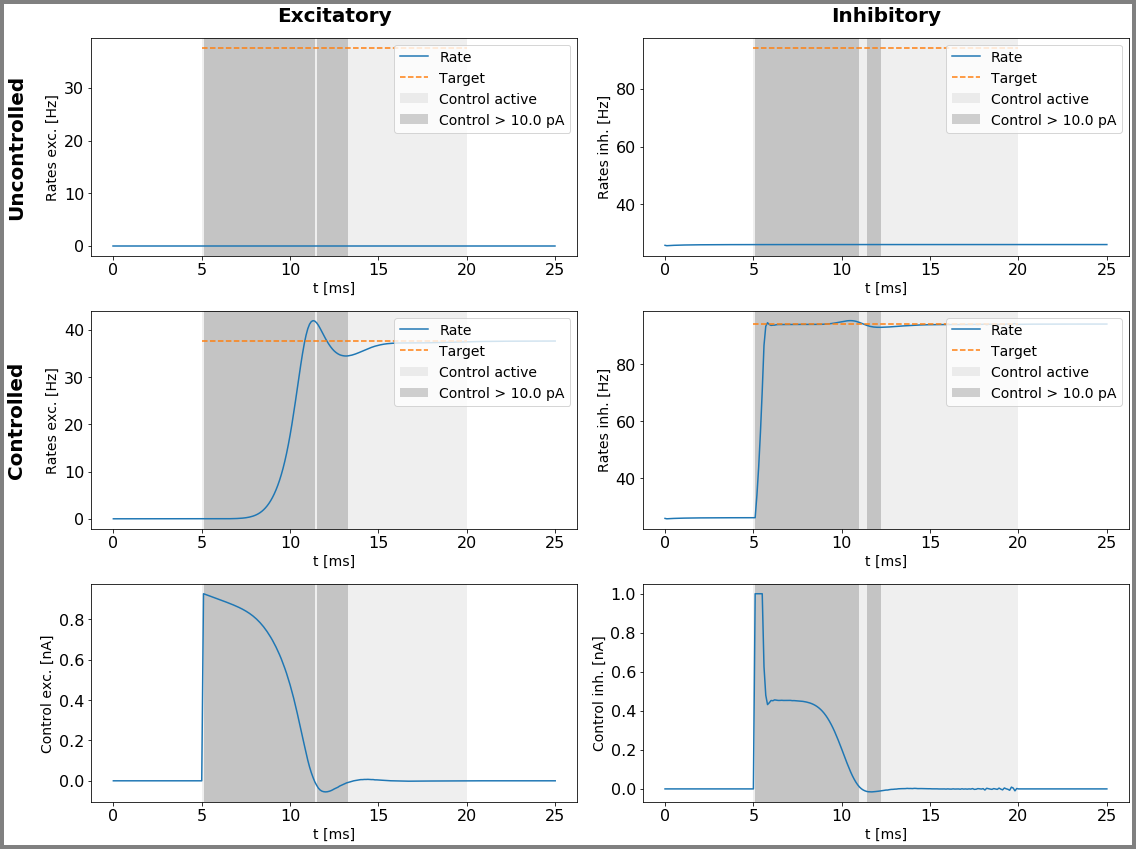

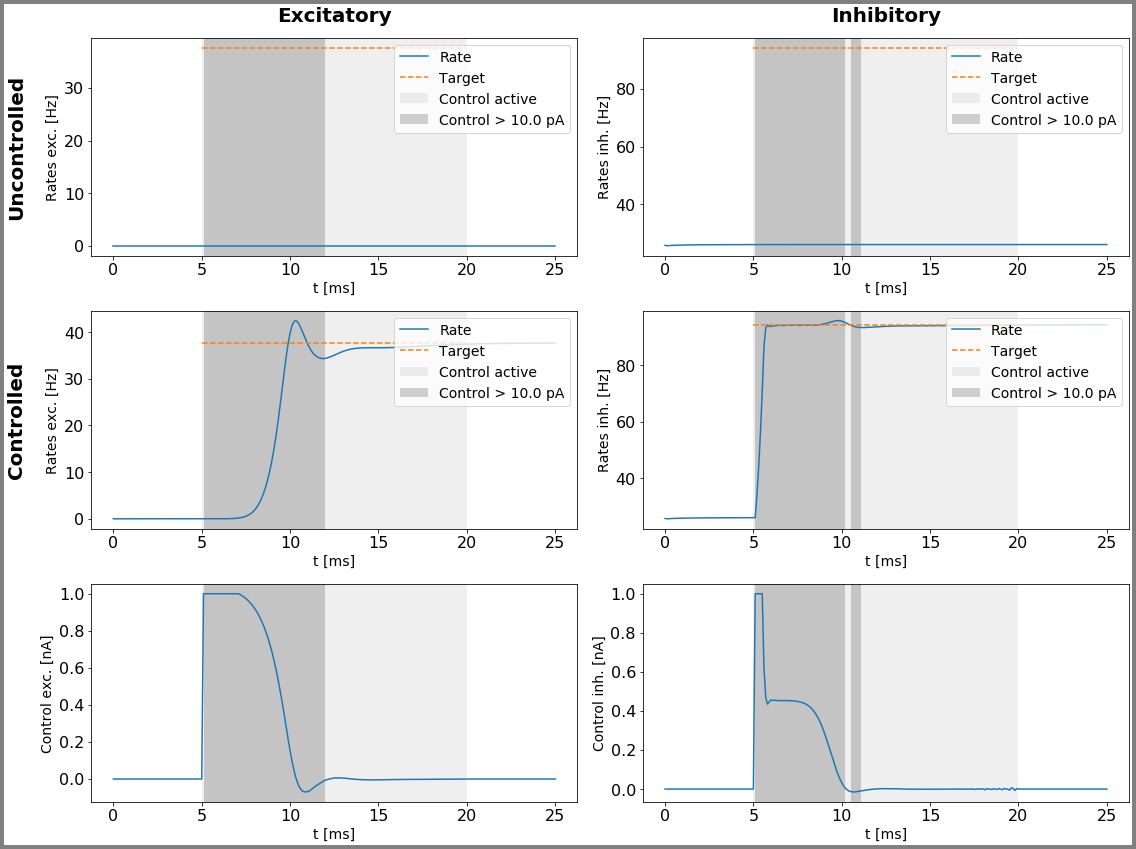

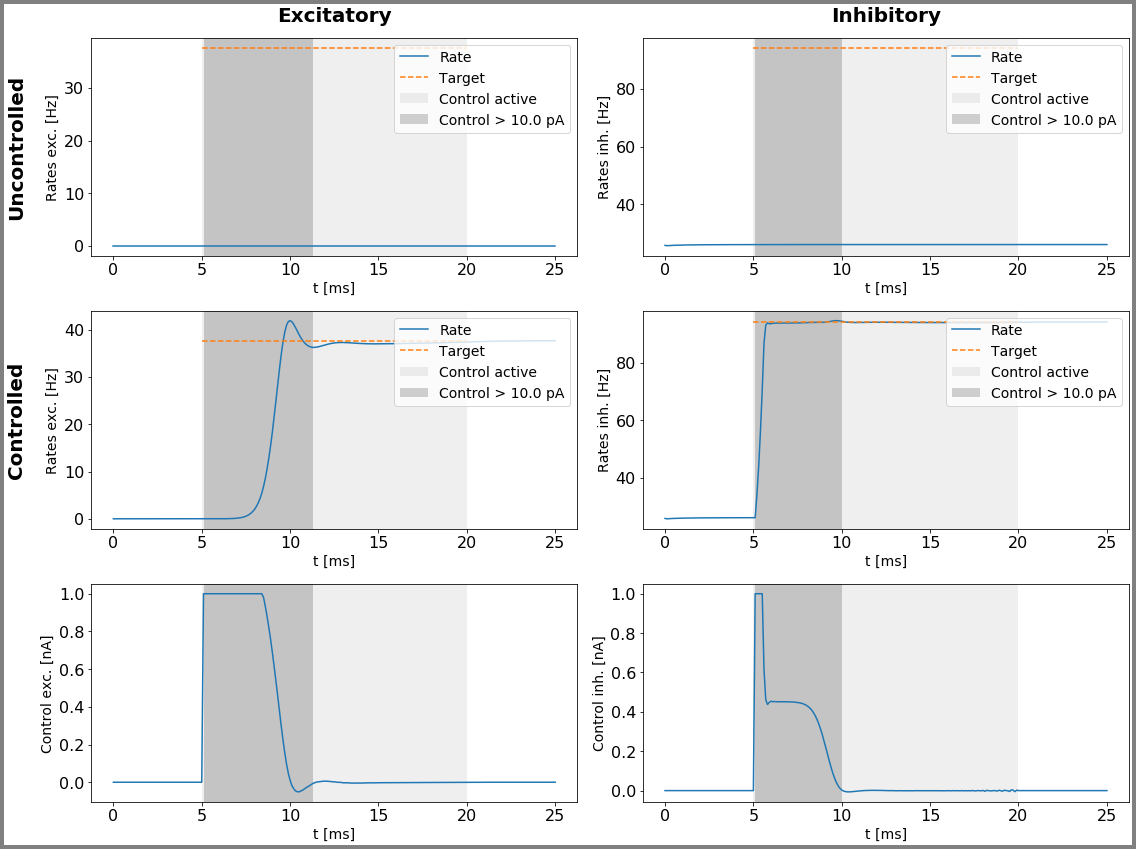

In [29]:
for i in range(loop_it):
    setinitvars(low_state_vars)
    
    cntrlA1_, bestStateA1_, costA1_, runtimeA1_, grad = aln.A1(cntrl1, target_lh, c_scheme, u_mat, u_scheme,
            max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post)
    
    #if (i % 10 == 0):
    plotFunc.plot_control(aln, cntrlA1_, dur, dur_pre, dur_post, low_state_vars, target_lh,
                      path, filename_ = str('p1_e1_u1nA_LowHigh_' + alg + "_" + str(i*max_it) ))
    
    cntrl1 = cntrlA1_[:,:,50:201]
    if i == 0:
        costA1[0] = costA1_[0]
    costA1[max_it*i+1:max_it*i+max_it+1] = costA1_[1:]
    runtimeA1[max_it*i+1:max_it*i+max_it+1] = runtimeA1[max_it*i] + runtimeA1_[1:]

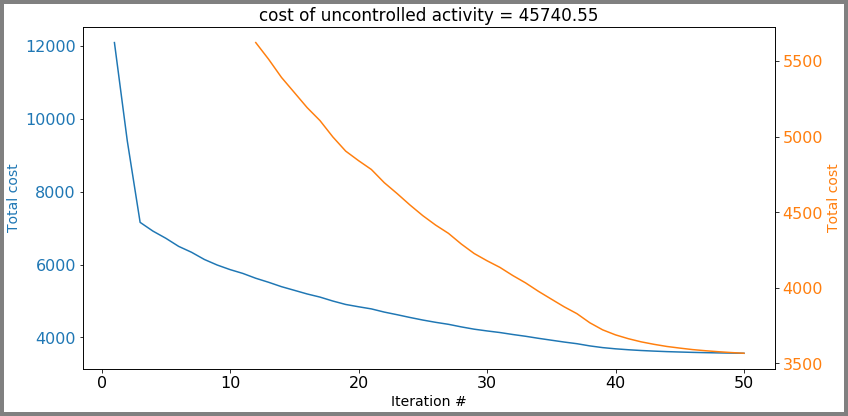

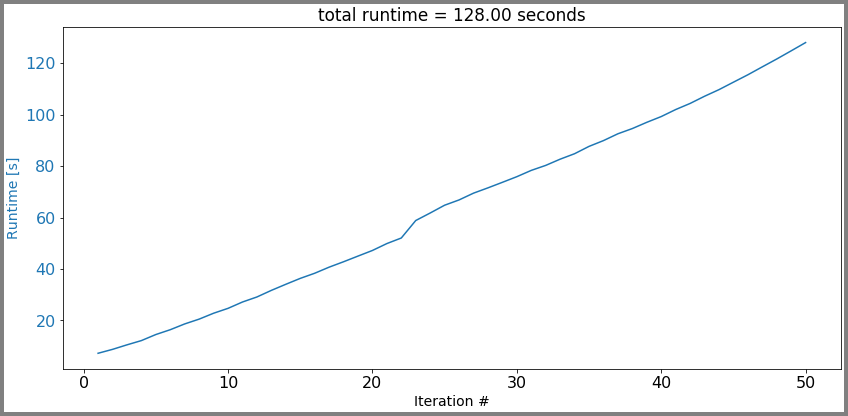

In [30]:
#print(costA1)
#print(costD)
costA1 = np.array(costA1[:])
#print(runtimeA1)
runtimeA1 = np.array(runtimeA1[:])
plotFunc.plot_convergence(costA1, path, str("p1_e1_u1nA_LowHigh_cost_" + alg) )
plotFunc.plot_runtime(runtimeA1, path, str("p1_e1_u1nA_LowHigh_runtime_" + alg))

In [21]:
cntrl1 = control0
alg = "A2"

max_it = 5
loop_it = 5
costA2 = np.zeros(max_it*loop_it + 1)
runtimeA2 = np.zeros(max_it*loop_it + 1)

True
RUN  0 , total integrated cost:  45740.55028557171
RUN  1 , total integrated cost:  34194.502541617396
RUN  2 , total integrated cost:  23312.595232033997
RUN  3 , total integrated cost:  19097.84614861437
change helped, counter =  1
RUN  4 , total integrated cost:  13009.181841587928
change helped, counter =  1
change helped, counter =  1
change helped, counter =  1
RUN  5 , total integrated cost:  12385.032237361895
Improved over  5  iterations by  73  percent.


ERROR:root:Wrong dimension in control array input


True
1 1
2 2
51 151


IndexError: index 51 is out of bounds for axis 2 with size 51

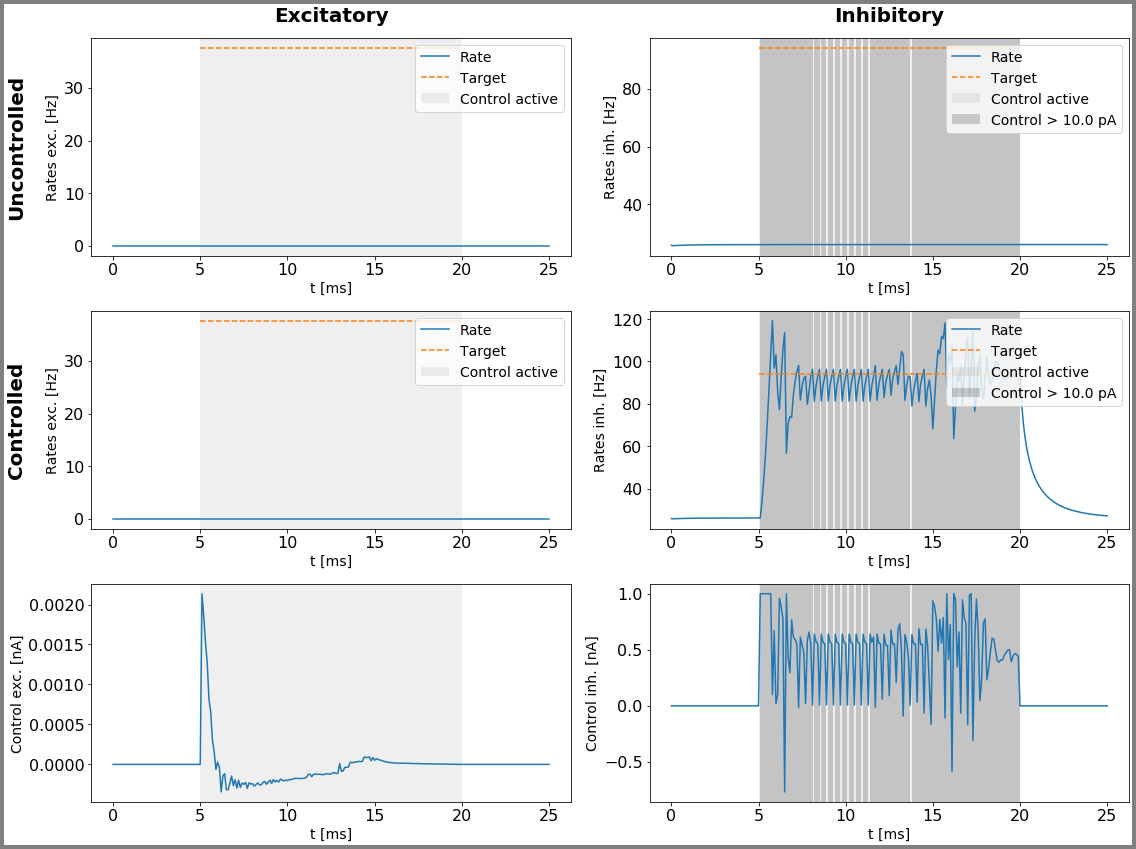

In [22]:
for i in range(loop_it):
    setinitvars(low_state_vars)
    cntrlA2_, bestStateA2_, costA2_, runtimeA2_ = aln.A2(cntrl1, target_lh, max_iteration_ = max_it, tolerance_ = tol,
                    include_timestep_ = incl_step, start_step_ = start_step, test_step_ = test_step,
                    max_control_ = max_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post)
    
    #if (i % 10 == 0):
    plotFunc.plot_control(aln, cntrlA2_, dur, dur_pre, dur_post, low_state_vars, target_lh,
                      path, filename_ = str('p1_e1_u1nA_LowHigh_' + alg + "_" + str(i*max_it) ))
    
    cntrl1 = cntrlA2_[:,:,50:201]
    if i == 0:
        costA2[0] = costA2_[0]
    costA2[max_it*i+1:max_it*i+max_it+1] = costA2_[1:]
    runtimeA2[max_it*i+1:max_it*i+max_it+1] = runtimeA2[max_it*i] + runtimeA2_[1:]

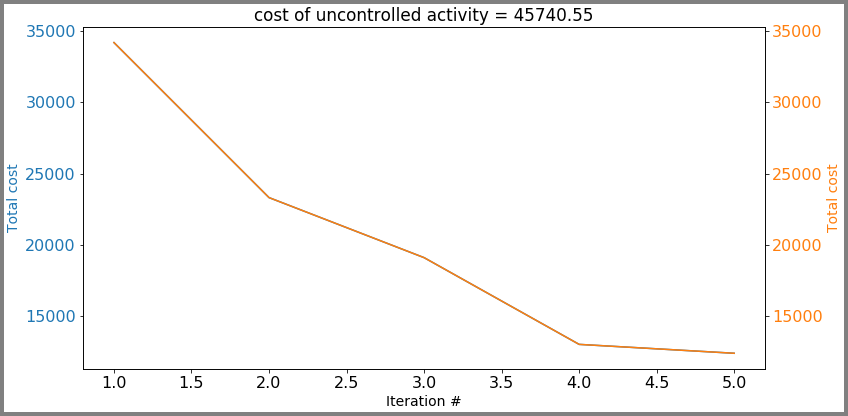

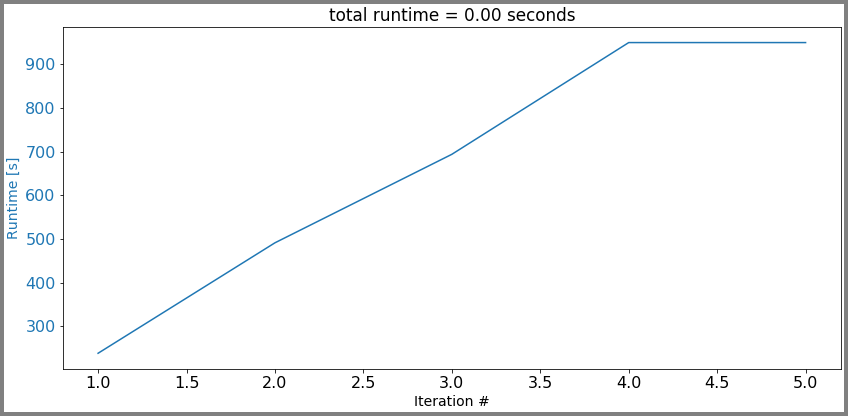

In [23]:
costA2 = np.array(costA2[:])
runtimeA2 = np.array(runtimeA2[:])
plotFunc.plot_convergence(costA2, path, str("p1_e1_u1nA_LowHigh_cost_" + alg) )
plotFunc.plot_runtime(runtimeA2, path, str("p1_e1_u1nA_LowHigh_runtime_" + alg))

cost A1 =  11633.738365725396
cost A2 =  0.0
runtime A1 =  122.39405110000007
runtime A2 =  0.0


ValueError: x and y must have same first dimension, but have shapes (51,) and (251,)

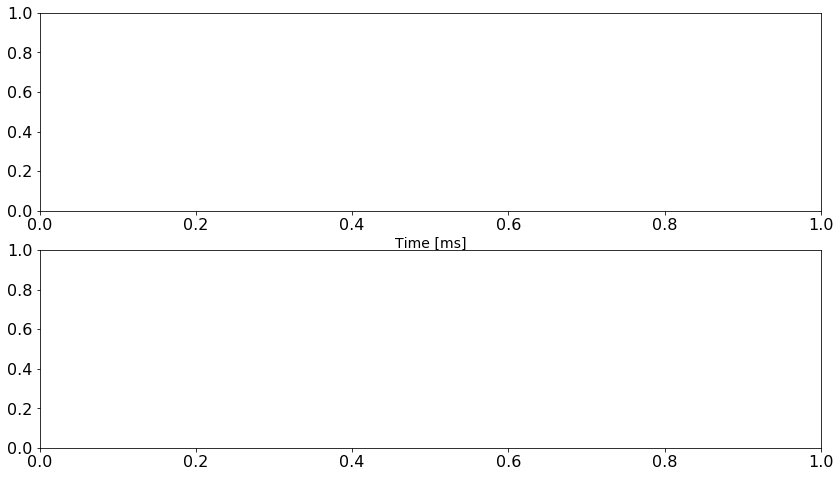

In [24]:
diff_cntrl = (cntrlA1_ - cntrlA2_)
diff_state = (bestStateA1_[:,:3,:] - bestStateA2_)
diff_cost = costA1[-1] - costA2[-1]
diff_runtime = runtimeA1[-1] - runtimeA2[-1]

print("cost A1 = ", costA1[-1])
print("cost A2 = ", costA2[-1])
print("runtime A1 = ", runtimeA1[-1])
print("runtime A2 = ", runtimeA2[-1])

fig, axes = plt.subplots(2, figsize=(14, 8))

color = 'tab:blue'
axes[0].set_xlabel('Time [ms]')
axes[0].plot(aln.t, diff_cntrl[0,0,:], label="difference in exc control", color=color)
axes[0].tick_params(axis='y', labelcolor=color)
axes[1].set_xlabel('Time [ms]')
axes[1].plot(aln.t, diff_state[0,0,:], label="difference in exc rate", color=color)
axes[1].tick_params(axis='y', labelcolor=color)

ax1 = axes[0].twinx() 
color = 'tab:orange'
ax1.plot(aln.t, diff_cntrl[0,1,:], label="difference in inh control", color=color)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = axes[1].twinx() 
color = 'tab:orange'
ax2.plot(aln.t, diff_state[0,1,:], label="difference in inh rate", color=color)
ax2.tick_params(axis='y', labelcolor=color)

for i in range(2):
    axes[i].legend()
ax1.legend()
ax2.legend()
    
fig.tight_layout()  # otherwise the right y-label is slightly clipped

plt.savefig(os.path.join(path,"p1_e1_u1nA_LowHigh_compare"))

In [21]:
rate = aln.params.precalc_r
v = aln.params.precalc_V
tau = aln.params.precalc_tau_mu

ir = aln.params.Irange
sr = aln.params.sigmarange

def getindex(lower, upper, length, x_):
    return int( (x_ - lower) * (length-1) / (upper - lower) )

def get_value(lower, upper, length, index_):
    return lower + index_ * (upper - lower) / (length-1)

gradient_r = np.zeros(( len(ir), len(sr), 2 ))
gradient_v = np.zeros(( len(ir), len(sr), 2 ))
gradient_t = np.zeros(( len(ir), len(sr), 2 ))
for sigma in range(len(sr)-1):
    for mu in range(len(ir)-1):
        res0 = jac_aln.der_mu_up(aln, sr[sigma], ir[mu], rate)
        res1 = jac_aln.der_sigma(aln, sr[sigma], ir[mu], rate)
        gradient_r[mu, sigma, 0] = res0
        gradient_r[mu, sigma, 1] = res1
        res0 = jac_aln.der_mu_up(aln, sr[sigma], ir[mu], v)
        res1 = jac_aln.der_sigma(aln, sr[sigma], ir[mu], v)
        gradient_v[mu, sigma, 0] = res0
        gradient_v[mu, sigma, 1] = res1
        res0 = jac_aln.der_mu_up(aln, sr[sigma], ir[mu], tau)
        res1 = jac_aln.der_sigma(aln, sr[sigma], ir[mu], tau)
        gradient_t[mu, sigma, 0] = res0
        gradient_t[mu, sigma, 1] = res1
        
